🔁 Pred view refresh at 2025-10-28 18:46:00
Querying last 120 minutes from table 'bch_usdt_1m_logreg_base' since 2025-10-28 16:46:00


,open_time,target_prob
47,2025-10-28 17:33:00,0.074900
46,2025-10-28 17:32:00,0.071160
45,2025-10-28 17:31:00,0.067394
44,2025-10-28 17:30:00,0.066501
43,2025-10-28 17:29:00,0.065883


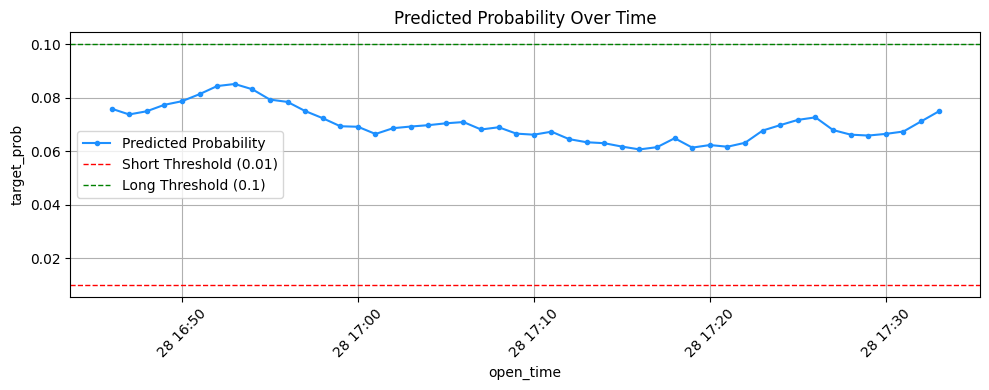

In [ ]:
# =============================================================================
# Modules
# =============================================================================
import time
import sys
import os
import sqlite3
import subprocess
import json
import threading

import utils                          as utils
import database_codes.bch_usdt_1m     as bch_1m
import database_codes.bch_usdt_1m_dev as bch_1m_dev
import database_codes.pred_view      as pred_view

from datetime        import datetime, timedelta
from IPython.display import clear_output  # Required for clearing the output in Jupyter Notebook

# =============================================================================
# Global variables for logging / background threads
# =============================================================================
logs = []
_pred_thread = None  # background thread for pred_view (keeps reference)

# =============================================================================
# Logging utilities
# =============================================================================
def log_message(message, section=False):
    # Insert timestamped log entries and refresh display.
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    if section:
        logs.insert(0, f"\n{'='*40}\n[{timestamp}] {message}\n{'='*40}")
    else:
        logs.insert(0, f"[{timestamp}] {message}")
    display_logs()

def display_logs():
    # Clear previous output and print logs (works inside Jupyter).
    clear_output(wait=True)
    for log in logs:
        print(log)

# =============================================================================
# Helper: start pred_view in background (single instance)
# =============================================================================
def _start_pred_view_background():
    """
    Start pred_view.run_pred_view() in a daemon background thread if not already started.
    This keeps the main scheduler running while a simple live plot runs concurrently.
    """
    global _pred_thread
    if _pred_thread is None or not _pred_thread.is_alive():
        try:
            _pred_thread = threading.Thread(
                target=pred_view.run_pred_view,
                name="pred_view_thread",
                daemon=True
            )
            _pred_thread.start()
            log_message("Started pred_view background thread.", section=True)
        except Exception as e:
            log_message(f"Failed to start pred_view thread: {e}")

# =============================================================================
# Scheduler loop
# =============================================================================
try:
    # start the pred_view once in background (will run concurrently)
    _start_pred_view_background()

    while True:
        # ---------------------------------------------------------------------
        # Current local time (system local). Rounded to minute (no timezone math).
        # ---------------------------------------------------------------------
        now_local = datetime.now().replace(second=0, microsecond=0)
        log_message(f"Cycle start — current local time: {now_local.strftime('%Y-%m-%d %H:%M:%S')}", section=True)

        # ---------------------------------------------------------------------
        # Load configuration and resolve database/table names
        # ---------------------------------------------------------------------
        cfg = utils._load_config()
        db_path    = cfg.get("database", {}).get("db_path")
        base_table = cfg.get("database", {}).get("dev_data", {}).get("table_name") or cfg.get("database", {}).get("table_name")
        dev_table  = cfg.get("database", {}).get("dev_data", {}).get("table_name_dev")

        # ---------------------------------------------------------------------
        # Query the DB for the maximum open_time in base and dev tables.
        # If dev table does not exist or is empty, use "2017-01-01 00:00:00".
        # Note: open_time fields are plain formatted timestamps in the DB.
        # ---------------------------------------------------------------------
        with sqlite3.connect(db_path) as conn:
            cur = conn.cursor()
            # base max
            cur.execute(f'SELECT MAX("open_time") FROM "{base_table}"')
            base_row = cur.fetchone()
            base_max = base_row[0] if base_row and base_row[0] is not None else None

            # dev max: if dev table does not exist or is empty, use default "2017-01-01 00:00:00"
            cur.execute("SELECT name FROM sqlite_master WHERE type='table' AND name=?", (dev_table,))
            if cur.fetchone() is None:
                # table missing -> use default start
                dev_max = "2017-01-01 00:00:00"
            else:
                cur.execute(f'SELECT MAX("open_time") FROM "{dev_table}"')
                dev_row = cur.fetchone()
                # if table exists but has no rows, fallback to default as well
                dev_max = dev_row[0] if dev_row and dev_row[0] is not None else "2017-01-01 00:00:00"

        # ---------------------------------------------------------------------
        # Helper to compute next minute or fallback default.
        # Input: timestamp string, attempts ISO parse then strptime.
        # Returns: formatted string "YYYY-MM-DD HH:MM:SS".
        # ---------------------------------------------------------------------
        def _next_min_or_default(max_ts, default_start="2007-01-01 00:00:00"):
            if max_ts is None:
                return default_start
            try:
                dt = datetime.fromisoformat(max_ts)
            except Exception:
                dt = datetime.strptime(max_ts, "%Y-%m-%d %H:%M:%S")
            # For syncs we usually start at the minute after the last stored record.
            return (dt + timedelta(minutes=1)).strftime("%Y-%m-%d %H:%M:%S")

        # ---------------------------------------------------------------------
        # Prepare time ranges for base and dev syncs.
        # Use local system time as 'to' timestamp.
        # ---------------------------------------------------------------------
        base_sync_from = _next_min_or_default(base_max)
        base_sync_to   = now_local.strftime("%Y-%m-%d %H:%M:%S")

        log_message(f"Will sync base table '{base_table}' from {base_sync_from} to {base_sync_to}")
        try:
            # The sync function receives start and end as formatted local-time strings.
            bch_1m.sync_bchusdt_1m(base_sync_from, base_sync_to)
            log_message("Base table sync finished.")
        except Exception as e:
            log_message(f"Error during base table sync: {e}")

        # ---------------------------------------------------------------------
        # Dev update: same logic, compute start from dev_max + 1 minute
        # ---------------------------------------------------------------------
        dev_sync_from = _next_min_or_default(dev_max)
        dev_sync_to   = now_local.strftime("%Y-%m-%d %H:%M:%S")

        log_message(f"Will update dev table '{dev_table}' from {dev_sync_from} to {dev_sync_to}")
        try:
            bch_1m_dev.create_dev_data_table(dev_sync_from, dev_sync_to)
            log_message("Dev table update finished.")
        except Exception as e:
            log_message(f"Error during dev table update: {e}")

        # ---------------------------------------------------------------------
        # Build / update logistic-regression base table (logreg)
        # Logic:
        #  - Determine earliest start as last open_time in final logreg table + 1 min
        #  - If final table missing -> default "2017-01-01 00:00:00"
        #  - Call create_logreg_base(from, to) with computed interval
        # ---------------------------------------------------------------------
        final_table_name = cfg.get("model", {}).get("logreg_base_table") or "bch_usdt_1m_logreg_base"
        with sqlite3.connect(db_path) as conn:
            cur = conn.cursor()
            cur.execute("SELECT name FROM sqlite_master WHERE type='table' AND name=?", (final_table_name,))
            if cur.fetchone() is None:
                logreg_max = "2017-01-01 00:00:00"
            else:
                cur.execute(f'SELECT MAX("open_time") FROM "{final_table_name}"')
                row = cur.fetchone()
                logreg_max = row[0] if row and row[0] is not None else "2017-01-01 00:00:00"

        logreg_sync_from = _next_min_or_default(logreg_max)
        logreg_sync_to   = now_local.strftime("%Y-%m-%d %H:%M:%S")

        log_message(f"Will update logreg table '{final_table_name}' from {logreg_sync_from} to {logreg_sync_to}")
        try:
            # call the logreg builder (creates/appends final feature table)
            logreg.create_logreg_base(logreg_sync_from, logreg_sync_to)
            log_message("Logreg base table update finished.")
        except Exception as e:
            log_message(f"Error during logreg base update: {e}")

        # ---------------------------------------------------------------------
        # Cycle complete: wait for next cycle
        # ---------------------------------------------------------------------
        log_message("Cycle complete — waiting for next cycle.")
        time.sleep(30)

except KeyboardInterrupt:
    # Attempt graceful shutdown note: pred_view is a daemon thread and will exit when
    # main process exits. We log the interruption and exit.
    log_message("Scheduler interrupted. Exiting...", section=True)